## DINOv2 LSTM ##

In [19]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm

from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix


import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader


import os
import pickle
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

## Device

In [20]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# device = torch.device("cpu")
device

device(type='cuda')

## Load DinoV2

## Prepare Dataset

In [21]:
# pose_pickle_folder = '/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/0001/User_2_001.pickle'
pose_pickle_folder = '/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/'

def get_active_frames_from_pickle(input_raw) -> np.ndarray:
    threshold = (
        (((input_raw["pose"]["left_hip"][:, 1] + input_raw["pose"]["right_hip"][:, 1]) / 2 )* 7)
        + input_raw["pose"]["nose"][:, 1] * 3
    ) / 10

    active_frames = (
        np.minimum(
            input_raw["hand_left"]["left_lunate_bone"][:, 1],
            input_raw["hand_right"]["right_lunate_bone"][:, 1],
        )
        < threshold
    )

    active_frame_indices = np.argwhere(active_frames).squeeze()
    return active_frame_indices


def get_active_frames(label_name, sample_name):
    pickle_file_name = f"{pose_pickle_folder}/{label_name}/{sample_name}.pickle"
    file = open(pickle_file_name, 'rb')
    input_raw = pickle.load(file)

    return get_active_frames_from_pickle(input_raw)

In [ ]:
####### SECOND #######


frame_frequency = 2

def create_label_dict(classes):
    label_dict = {}
    for i in range(0,len(classes)):
        label_dict[classes[i]] = i
    return label_dict

class CustomImageDataset(Dataset):
    def __init__(self, deephand_root_dir, dino_root_dir):
        deephand_pickle_file = open(deephand_root_dir, 'rb')
        deephand_paths, deephand_features, deephand_labels = pickle.load(deephand_pickle_file)

        dino_pickle_file = open(dino_root_dir, 'rb')
        dino_paths, dino_features,dino_labels = pickle.load(dino_pickle_file)

        self.deephand_features = deephand_features
        self.dino_features = dino_features
        self.paths = dino_paths
        self.classes = np.unique(dino_labels)
        label_dict = create_label_dict(self.classes)
        self.labels = [label_dict[x] for x in dino_labels]

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        splited_paths = self.paths[idx].split('/')

        active_frame_indices = get_active_frames(splited_paths[-2],splited_paths[-1])
        active_frame_indices = (
            active_frame_indices
            if active_frame_indices.size > 10
            else np.arange(0, len(self.deephand_features[idx]))
        )
        deephand_embeddings = [self.deephand_features[idx][i] for i in active_frame_indices]
        dino_embeddings = [self.dino_features[idx][i] for i in active_frame_indices]
        deephand_embeddings = deephand_embeddings[0::frame_frequency]
        dino_embeddings = dino_embeddings[0::frame_frequency]
        embeddings = np.concatenate((deephand_embeddings, dino_embeddings), axis=1)

        np_stacked_array = np.stack(embeddings)
        tensor = torch.from_numpy(np_stacked_array)
        # trX = torch.stack(embeddings).float()
        return tensor, self.labels[idx] 


In [23]:
# image_dataset = CustomImageDataset()

# train_dataset, test_dataset = torch.utils.data.random_split(image_dataset, [0.85, 0.15])

train_dataset = CustomImageDataset('/media/osero/SamsungSSD/pickles/deephand_left_frames_train.pickle', '/media/osero/SamsungSSD/pickles/features_left_hand_frames_small_train.pickle')
test_dataset = CustomImageDataset('/media/osero/SamsungSSD/pickles/deephand_left_frames_test.pickle', '/media/osero/SamsungSSD/pickles/features_left_hand_frames_small_test.pickle')

cc = 5


In [24]:
batch_size = 1
num_workers = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # Adjust batch size as needed
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)



In [25]:
class_names = train_dataset.classes
class_names

input_dim = train_dataset[0][0][0].size(0)  # Get input dimension from a single feature from a video
num_classes = len(set(train_dataset.classes))
print("input_dim: ", input_dim, " num_classes: ", num_classes)
print("train_dataset size: ", len(train_dataset))
print("test_dataset size: ", len(test_dataset))

input_dim:  1408  num_classes:  744
train_dataset size:  18018
test_dataset size:  4524


## Model

In [26]:
# class DinoVisionTransformerClassifier(nn.Module):
#     def __init__(self, input_dim, num_classes):
#         super(DinoVisionTransformerClassifier, self).__init__()
#         self.classifier = nn.Sequential(
#             nn.Linear(input_dim, 256),
#             nn.ReLU(),
#             nn.Linear(256, num_classes)
#         )
    
#     def forward(self, x):
#         x = self.classifier(x)
#         return x
    
# model = DinoVisionTransformerClassifier(input_dim=input_dim, num_classes=num_classes)
# model = model.to(device)


class VideoClassifierLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(VideoClassifierLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout = 0.2)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # LSTM expects input shape: (batch, seq, features)
        _, (hidden, _) = self.lstm(x)  # Use last hidden state
        output = self.dropout(hidden[-1])
        output = self.fc(output)  # Take hidden state of the last LSTM layer
        return output

    
hidden_dim = 256
num_layers = 2
model = VideoClassifierLSTM(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers, num_classes=num_classes)
model = model.to(device)

## Functions

In [27]:
def test_images():
    correct = 0
    top_5_correct = 0
    total = 0
    running_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    test_predicted = []
    test_labels = []

    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            labels = labels.to(device)

            # calculate outputs by running images through the network
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.topk(outputs.data, 1)
            _, predicted_top_5 = torch.topk(outputs.data, 5)
            total += labels.size(0)
            correct += (predicted.to(device) == labels).sum().item() 
            top_5_correct += (predicted_top_5.to(device) == labels).any().sum().item()
            running_loss += loss.item()

            test_labels += (labels.cpu().numpy().tolist())
            test_predicted += (predicted.cpu().numpy().tolist())

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    top_5_accuracy = 100 * top_5_correct / total
    print(f'Accuracy of the network on the {len(test_loader)*batch_size} test video: {accuracy:.4f} %, top5: {top_5_accuracy:.4f} %, avg_loss: {avg_loss}')
    return accuracy, top_5_accuracy, avg_loss

In [28]:
import datetime
from time import gmtime, strftime
def get_current_time():
    return strftime("%Y-%m-%d_%H-%M-%S", gmtime())

def save_model_result(current_time):
    result_name = 'lstm_results/Deephand_dino_' + current_time + '.pth'
    torch.save({'name': result_name,
                'model_state_dict': model.state_dict(),
                'lr': lr,
                'step_size': step_size,
                'gamma': gamma,
                'weight_decay': weight_decay,
                'hidden_dim': hidden_dim,
                'num_layers': num_layers,
                'batch_size': batch_size,
                'frame_frequency': frame_frequency,
                'input_dim': input_dim,
                'num_classes': num_classes,
                'train_dataset': len(train_dataset),
                'test_dataset': len(test_dataset),
                'avg_loss_list': avg_loss_list,
                'avg_accuracy_list': avg_accuracy_list,
                'avg_test_accuracy_list': avg_test_accuracy_list,
                'avg_top5_test_accuracy_list': avg_top5_test_accuracy_list,
                'avg_test_loss_list': avg_test_loss_list},
                result_name)



In [29]:
import shutil
def copy_ipynb_file(current_time): 
    current_file = 'deephand_dino_left.ipynb'
    copy_file = '/home/osero/Desktop/CMPE/dinov2/classsification/lstm/lstm_results/ipynbs/COPY_' + current_time + '_' + current_file
    shutil.copy(current_file, copy_file)

## Train

In [30]:
lr = 0.0001
step_size = 10
gamma = 0.5
weight_decay = 0

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)
scheduler = lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma) ## CosineAnnealingLR Dene
print(f"lr {lr}, step_size: {step_size}, gamma: {gamma}, weight_decay: {weight_decay}")
print(f"Model hidden_dim {hidden_dim}, num_layers: {num_layers}")
print(f"batch_size {batch_size}, frame_frequency: {frame_frequency}")

avg_loss_list = []
avg_accuracy_list = []
avg_test_accuracy_list = []
avg_top5_test_accuracy_list = []
avg_test_loss_list = []

num_epoch = 30
for epoch in range(num_epoch):
    train_acc = 0
    train_loss = 0
    loop = tqdm(train_loader)

    running_loss = 0.0
    running_accuracy= 0.0
    for idx, (features, labels) in enumerate(loop):
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)

        predictions = outputs.argmax(dim=1, keepdim=True).squeeze()
        correct = (predictions == labels).sum().item()
        accuracy = correct / batch_size

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_accuracy += 100 * accuracy
        loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
        loop.set_postfix(loss=loss.item(), acc=accuracy)
    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    avg_accuracy = running_accuracy / len(train_loader)
    print(f"Time: {get_current_time()} Epoch [{epoch}], Avg loss: {avg_loss:.4f}, Avg accuracy: {avg_accuracy:.4f}")
    avg_test_accuracy, avg_top5_test_accuracy, avg_test_loss = test_images()

    avg_loss_list.append(avg_loss)
    avg_accuracy_list.append(avg_accuracy)
    avg_test_accuracy_list.append(avg_test_accuracy)
    avg_top5_test_accuracy_list.append(avg_top5_test_accuracy)
    avg_test_loss_list.append(avg_test_loss)
current_time = get_current_time()
save_model_result(current_time)
copy_ipynb_file(current_time)

lr 0.0001, step_size: 10, gamma: 0.5, weight_decay: 0
Model hidden_dim 256, num_layers: 2
batch_size 1, frame_frequency: 3


Epoch [0/30]: 100%|██████████| 18018/18018 [01:23<00:00, 216.02it/s, acc=0, loss=3.66] 


Time: 2024-11-21_07-45-50 Epoch [0], Avg loss: 5.5825, Avg accuracy: 7.2483
Accuracy of the network on the 4524 test video: 17.6172 %, top5: 41.7330 %, avg_loss: 4.371607016426182


Epoch [1/30]: 100%|██████████| 18018/18018 [01:14<00:00, 242.34it/s, acc=1, loss=2.23]  


Time: 2024-11-21_07-47-11 Epoch [1], Avg loss: 3.3894, Avg accuracy: 35.7698
Accuracy of the network on the 4524 test video: 45.4244 %, top5: 78.8019 %, avg_loss: 2.866174233097428


...

Time: 2024-11-21_08-17-44 Epoch [27], Avg loss: 0.0296, Avg accuracy: 99.5171
Accuracy of the network on the 4524 test video: 83.6207 %, top5: 96.2423 %, avg_loss: 0.6890834788846655


Epoch [28/30]: 100%|██████████| 18018/18018 [01:05<00:00, 275.98it/s, acc=1, loss=0.000287]


Time: 2024-11-21_08-18-54 Epoch [28], Avg loss: 0.0281, Avg accuracy: 99.5005
Accuracy of the network on the 4524 test video: 82.6923 %, top5: 96.0212 %, avg_loss: 0.7085486302040545


Epoch [29/30]: 100%|██████████| 18018/18018 [01:05<00:00, 275.28it/s, acc=1, loss=0.000976]


Time: 2024-11-21_08-20-03 Epoch [29], Avg loss: 0.0271, Avg accuracy: 99.5504
Accuracy of the network on the 4524 test video: 83.7975 %, top5: 96.1317 %, avg_loss: 0.6830376631626092


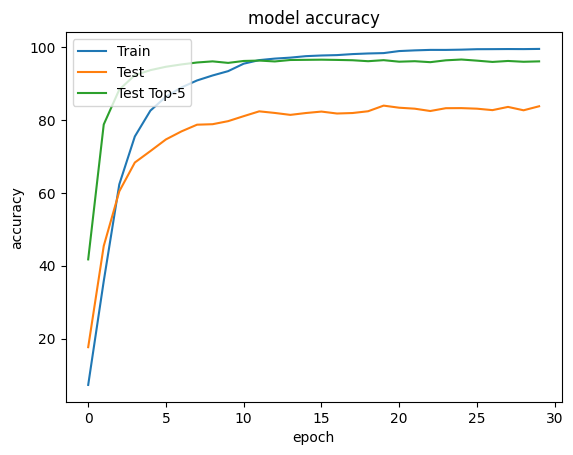

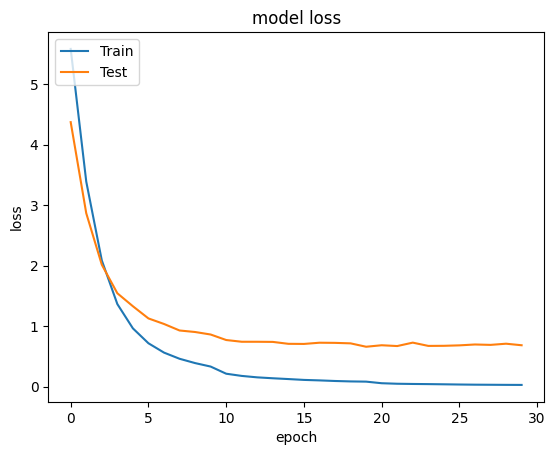

In [31]:
import matplotlib.pyplot as plt
import torch

# summarize history for accuracy
plt.plot(avg_accuracy_list) 
plt.plot(avg_test_accuracy_list)
plt.plot(avg_top5_test_accuracy_list)
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Test', 'Test Top-5'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(avg_loss_list)
plt.plot(avg_test_loss_list)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Test

In [32]:

test_images()

Accuracy of the network on the 4524 test video: 82.7144 %, top5: 96.2423 %, avg_loss: 0.694572445140618


(82.71441202475685, 96.24226348364279, 0.694572445140618)

## Report

In [33]:
# print(classification_report(test_labels, test_predicted, target_names=class_names))


In [34]:
# cm = confusion_matrix(test_labels, test_predicted)
# df_cm = pd.DataFrame(
#     cm, 
#     index = class_names,
#     columns = class_names
# )
# df_cm

In [35]:
# def show_confusion_matrix(confusion_matrix):
#     hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
#     plt.ylabel("Surface Ground Truth")
#     plt.xlabel("Predicted Surface")
#     plt.legend()
    
# show_confusion_matrix(df_cm)